# Step 2: Feature Selection

1. Use logistic regression and L1 regularization to select features

2. For high dimensional data: compare results between PCA and shrinking



In [1]:
import numpy as np
import pandas as pd

import shap

import os

from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

/Applications/anaconda3/envs/wids-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
current_dir = os.getcwd()
home_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
data_dir = os.path.join(home_dir, 'data/')

In [4]:
train_cat = pd.read_csv(os.path.join(data_dir, 'intermediate/encoded_train_cat.csv'))
train_quant = pd.read_csv(os.path.join(data_dir, 'intermediate/train_quant_filled.csv'))
train_quant_scaled = pd.read_csv(os.path.join(data_dir, 'intermediate/train_quant_scaled.csv'))

train_fcm_100 = pd.read_csv(os.path.join(data_dir, 'intermediate/train_pca_100.csv'))
train_fcm_500 = pd.read_csv(os.path.join(data_dir, 'intermediate/train_pca_500.csv'))
train_FCM = pd.read_csv(os.path.join(data_dir, 'TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv'))

train_label = pd.read_excel(os.path.join(data_dir, 'TRAIN_NEW/TRAINING_SOLUTIONS.xlsx'))

## Feature Importance Plot in Tree Model

### 1. Not include FCM

In [27]:
X = train_cat.merge(train_quant, on='participant_id', how='left')
X = X.drop(columns=['participant_id'])
y = train_label.copy()
y = y['ADHD_Outcome']

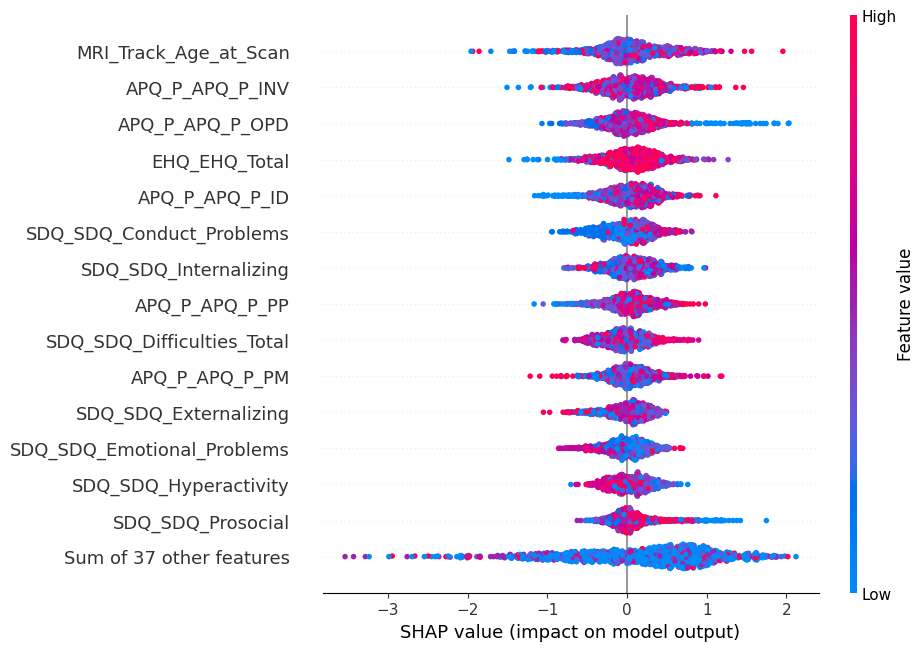

In [28]:
# Train a xgboost model
model = XGBClassifier().fit(X, y)

# Get the feature importances
explainer = shap.Explainer(model)
shap_values = explainer(X)

# Create SHAP beeswarm plot
shap.plots.beeswarm(explainer(X), max_display=15, show=True)

In [29]:
# print to 15 features
shap_values = shap_values.values
feature_importance = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame(list(zip(X.columns, feature_importance)), columns=['feature', 'importance'])
feature_importance = feature_importance.sort_values(by='importance', ascending=False)
feature_importance = feature_importance.head(15)

In [30]:
feature_importance

,feature,importance
50,MRI_Track_Age_at_Scan,0.325421
37,APQ_P_APQ_P_INV,0.277075
38,APQ_P_APQ_P_OPD,0.260916
33,EHQ_EHQ_Total,0.260583
36,APQ_P_APQ_P_ID,0.240738
41,SDQ_SDQ_Conduct_Problems,0.232385
47,SDQ_SDQ_Internalizing,0.220370
40,APQ_P_APQ_P_PP,0.213376
42,SDQ_SDQ_Difficulties_Total,0.210375
39,APQ_P_APQ_P_PM,0.199992


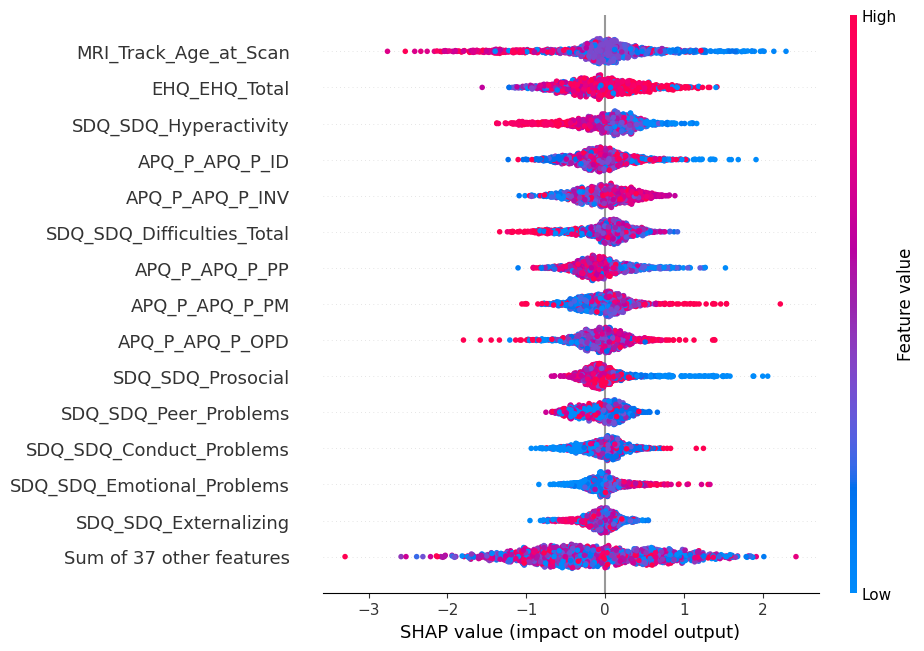

In [8]:
y = train_label.copy()
y = y['Sex_F']

# Train a xgboost model
model = XGBClassifier().fit(X, y)

# Get the feature importances
explainer = shap.Explainer(model)
shap_values = explainer(X)

# Create SHAP beeswarm plot
shap.plots.beeswarm(explainer(X), max_display=15, show=True)

### 2. Include FCM


In [14]:
X = train_cat.merge(train_quant, on='participant_id', how='left').merge(train_fcm_100, on='participant_id', how='left')
X = X.drop(columns=['participant_id'])

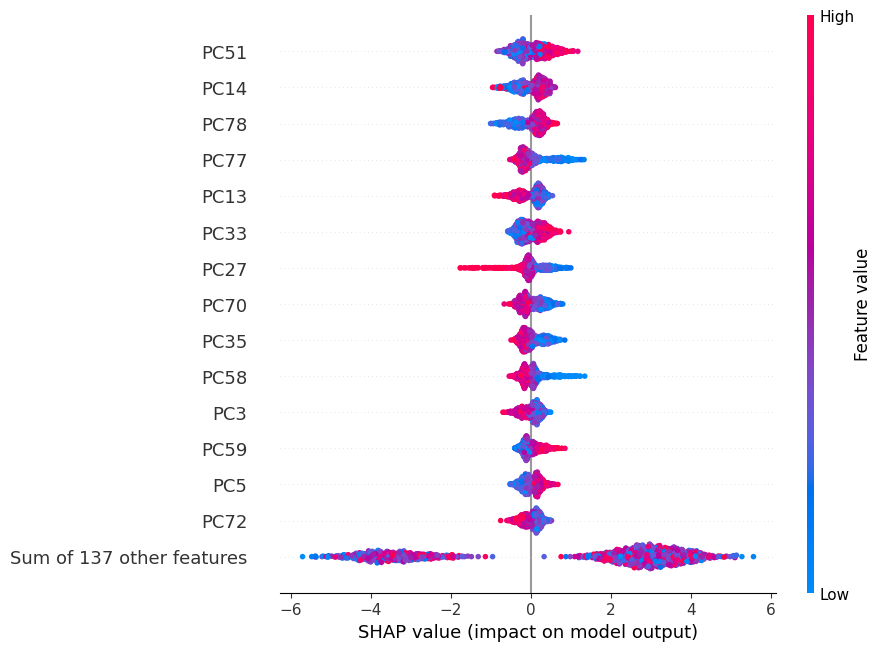

In [15]:
y = train_label.copy()
y = y['ADHD_Outcome']

# Train a xgboost model
model = XGBClassifier().fit(X, y)

# Get the feature importances
explainer = shap.Explainer(model)
shap_values = explainer(X)

# Create SHAP beeswarm plot
shap.plots.beeswarm(explainer(X), max_display=15, show=True)

Seems like Connectome features are very important!

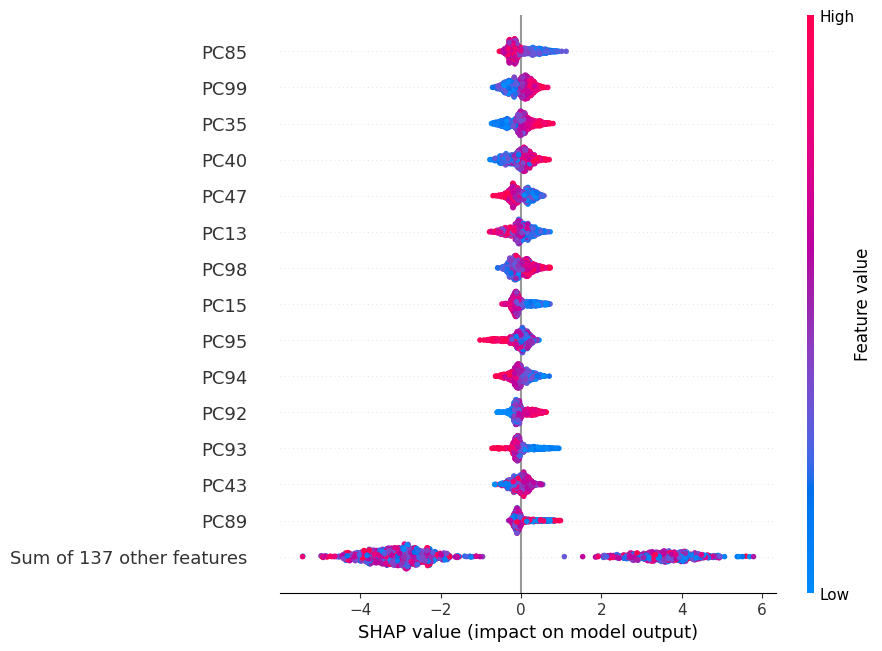

In [16]:
y = train_label.copy()
y = y['Sex_F']

# Train a xgboost model
model = XGBClassifier().fit(X, y)

# Get the feature importances
explainer = shap.Explainer(model)
shap_values = explainer(X)

# Create SHAP beeswarm plot
shap.plots.beeswarm(explainer(X), max_display=15, show=True)

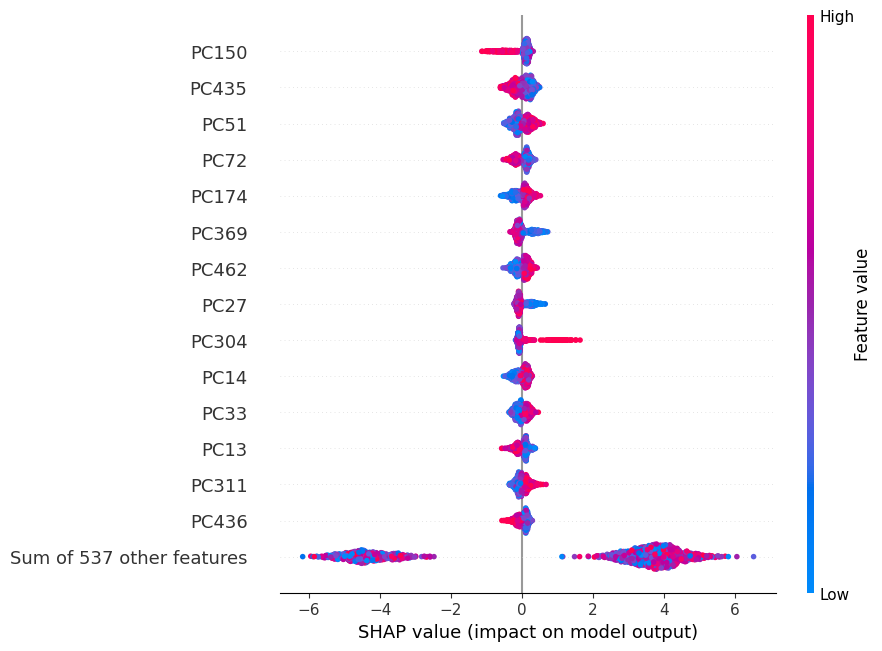

In [17]:
X = train_cat.merge(train_quant, on='participant_id', how='left').merge(train_fcm_500, on='participant_id', how='left')
X = X.drop(columns=['participant_id'])

y = train_label.copy()
y = y['ADHD_Outcome']

# Train a xgboost model
model = XGBClassifier().fit(X, y)

# Get the feature importances
explainer = shap.Explainer(model)
shap_values = explainer(X)

# Create SHAP beeswarm plot
shap.plots.beeswarm(explainer(X), max_display=15, show=True)

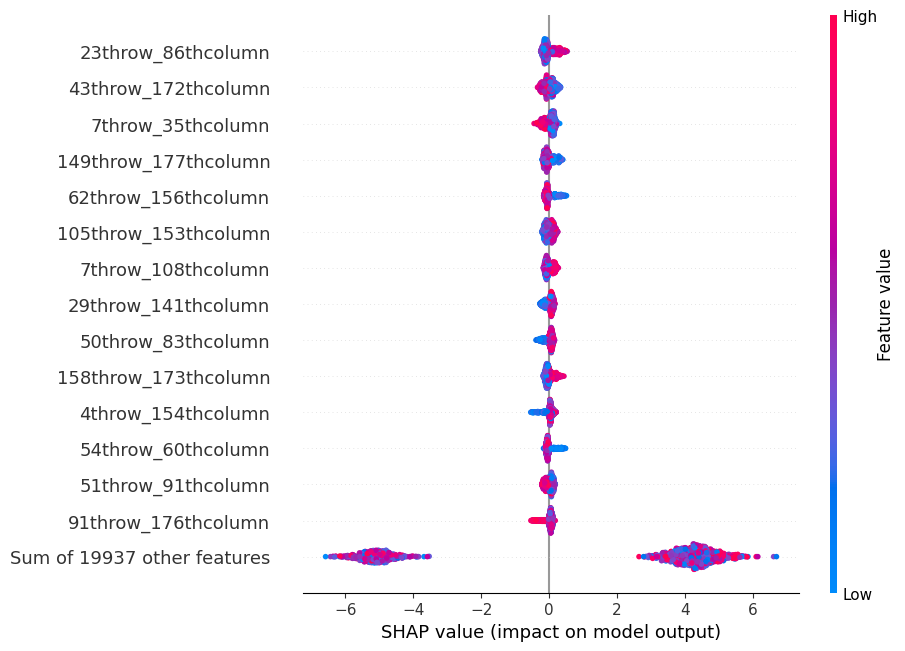

In [18]:
X = train_cat.merge(train_quant, on='participant_id', how='left').merge(train_FCM, on='participant_id', how='left')
X = X.drop(columns=['participant_id'])

y = train_label.copy()
y = y['ADHD_Outcome']

# Train a xgboost model
model = XGBClassifier().fit(X, y)

# Get the feature importances
explainer = shap.Explainer(model)
shap_values = explainer(X)

# Create SHAP beeswarm plot
shap.plots.beeswarm(explainer(X), max_display=15, show=True)

## Fit 2 Logistic Regression models with the two targets

Use regularization to shrink feature parameters

In [34]:
X = train_cat.merge(train_quant_scaled, on='participant_id', how='left').merge(train_fcm_500, on='participant_id', how='left')
X = X.drop(columns=['participant_id'])

y = train_label.copy()

**Using L1 regularization:**
- **Use L1 penalty**: Train a logistic regression model with L1 regularization. L1 regularization tends to shrink the coefficients of less important features to zero.
- **Select non-zero features:** Choose the features with non-zero coefficients.

In [35]:
model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(X, y['Sex_F'])

selected_features_Sex = X.columns[model.coef_[0] != 0]
print(selected_features_Sex)

Index(['MRI_Track_Scan_Location_3.0', 'Barratt_Barratt_P1_Edu_12.0',
       'Barratt_Barratt_P1_Edu_15.0', 'Barratt_Barratt_P1_Edu_18.0',
       'Barratt_Barratt_P1_Occ_30.0', 'Barratt_Barratt_P1_Occ_45.0',
       'Barratt_Barratt_P2_Edu_9.0', 'Barratt_Barratt_P2_Edu_15.0',
       'Barratt_Barratt_P2_Edu_18.0', 'Barratt_Barratt_P2_Occ_5.0',
       ...
       'PC490', 'PC491', 'PC492', 'PC493', 'PC494', 'PC495', 'PC496', 'PC497',
       'PC498', 'PC499'],
      dtype='object', length=487)


In [36]:
model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(X, y['ADHD_Outcome'])

selected_features_ADHD = X.columns[model.coef_[0] != 0]
print(selected_features_ADHD)

Index(['MRI_Track_Scan_Location_3.0', 'Barratt_Barratt_P1_Edu_9.0',
       'Barratt_Barratt_P1_Edu_12.0', 'Barratt_Barratt_P1_Edu_15.0',
       'Barratt_Barratt_P1_Edu_18.0', 'Barratt_Barratt_P1_Occ_5.0',
       'Barratt_Barratt_P1_Occ_15.0', 'Barratt_Barratt_P1_Occ_20.0',
       'Barratt_Barratt_P1_Occ_25.0', 'Barratt_Barratt_P1_Occ_30.0',
       ...
       'PC489', 'PC490', 'PC491', 'PC493', 'PC494', 'PC495', 'PC496', 'PC497',
       'PC498', 'PC499'],
      dtype='object', length=497)


In [37]:
# Find common features
common_features = list(set(selected_features_ADHD) & set(selected_features_Sex))

In [38]:
pd.DataFrame(common_features).to_csv(os.path.join(data_dir, 'intermediate/common_features_selected_500.csv'), index=False, header=False)